In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.special import erf 
from matplotlib.colors import LogNorm
from math import erf, sqrt, pi

In [2]:
mchi_keV = 3.7e3
me_keV   = 511.0                 
Tcore_keV= 1.1                   
ne_cm3   = 2.0e25                
Vcore_cm3= 2.2e31                
AU_cm    = 1.495978707e13       
rho0_GeVcm3 = 0.3               
v0_kms   = 220.0                 
vesc_kms = 1500.0
mchi_GeV = mchi_keV * 1e-6
mu_keV   = (mchi_keV * me_keV) / (mchi_keV + me_keV)

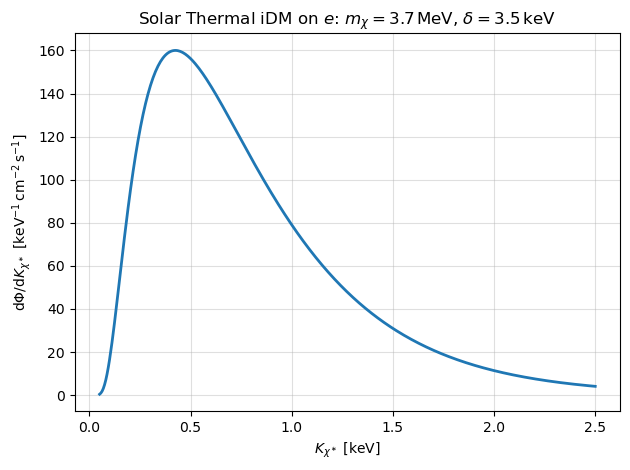

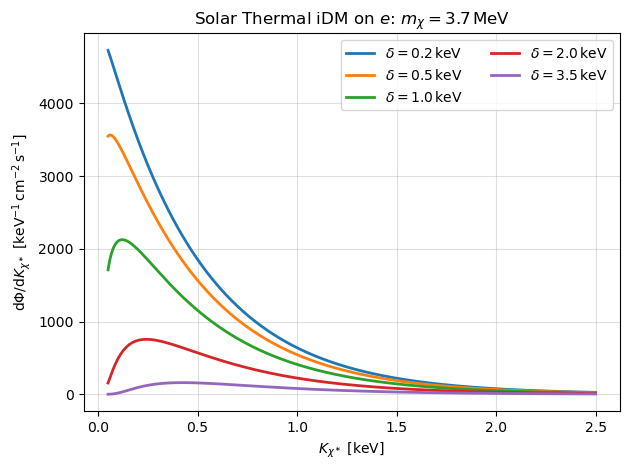

In [ ]:
n0_cm3   = rho0_GeVcm3 / mchi_GeV
nchi_core_cm3 = n0_cm3 * (vesc_kms / v0_kms)

#Model normalization: σ_e in cm^2
sigma_e_cm2 = 4.382e-28

def vmin_of_K(K_keV, mchi_keV, mu_keV, delta_keV):
    K = np.asarray(K_keV)
    return ((mchi_keV * K) / mu_keV + delta_keV) / np.sqrt(2.0 * mchi_keV * K)

def avg_factor(K_keV, delta_keV):
    vm = vmin_of_K(K_keV, mchi_keV, mu_keV, delta_keV)
    return np.sqrt(2.0/np.pi) * np.sqrt(me_keV / Tcore_keV) * np.exp(- me_keV * vm**2 / (2.0 * Tcore_keV))

def dsigmadK_avg(K_keV, delta_keV):
    return sigma_e_cm2 * mchi_keV / (2.0 * mu_keV**2) * avg_factor(K_keV, delta_keV)

def flux_differential(K_keV, delta_keV):
    geom = ne_cm3 * nchi_core_cm3 * Vcore_cm3 / (4.0 * np.pi * AU_cm**2)
    return geom * dsigmadK_avg(K_keV, delta_keV)  # [keV^-1 cm^-2 s^-1]

K_vals_keV = np.linspace(0.05, 2.5, 400)

delta_single_keV = 3.5
flux_single = flux_differential(K_vals_keV, delta_single_keV)

plt.figure(figsize=(6.4,4.8))
plt.plot(K_vals_keV, flux_single, lw=2)
plt.xlabel(r"$K_{\chi^\ast}\ \mathrm{[keV]}$")
plt.ylabel(r"$\mathrm{d}\Phi/\mathrm{d}K_{\chi^\ast}\ \mathrm{[keV^{-1}\,cm^{-2}\,s^{-1}]}$")
plt.title(r"Solar Thermal iDM on $e$: $m_\chi=3.7\,\mathrm{MeV}$, $\delta=3.5\,\mathrm{keV}$")
plt.grid(True, which="both", alpha=0.4)
plt.tight_layout()
plt.show()

delta_keV_list = [0.2, 0.5, 1.0, 2.0, 3.5]

plt.figure(figsize=(6.4,4.8))
for dkeV in delta_keV_list:
    y = flux_differential(K_vals_keV, dkeV)
    plt.plot(K_vals_keV, y, lw=2, label=rf"$\delta={dkeV}\,$keV")

plt.xlabel(r"$K_{\chi^\ast}\ \mathrm{[keV]}$")
plt.ylabel(r"$\mathrm{d}\Phi/\mathrm{d}K_{\chi^\ast}\ \mathrm{[keV^{-1}\,cm^{-2}\,s^{-1}]}$")
plt.title(r"Solar Thermal iDM on $e$: $m_\chi=3.7\,\mathrm{MeV}$")
plt.legend(ncol=2)
plt.grid(True, which="both", alpha=0.4)
plt.tight_layout()
plt.show()

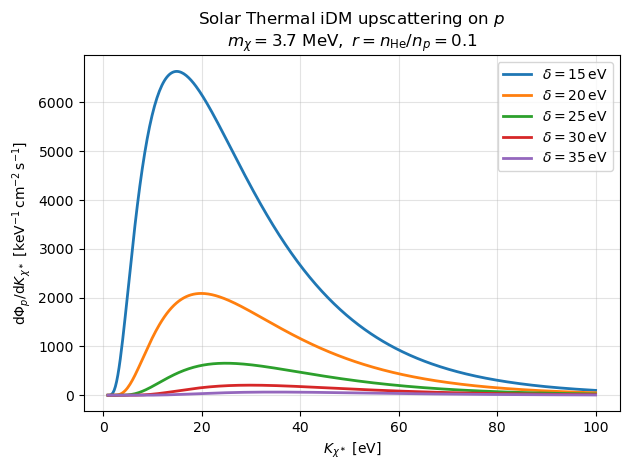

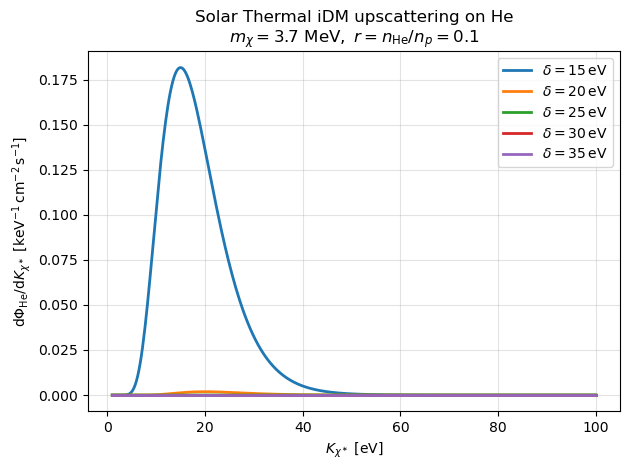

In [4]:
#Target densities in the core (fully ionized: n_e = n_p + 2 n_He)
r = 0.1
np_cm3  = ne_cm3 / (1.0 + 2.0*r)
nHe_cm3 = r * np_cm3

mp_keV  = 938_272.0813
mHe_keV = 3_727_300.0

def mu_red(m1, m2):
    return (m1 * m2) / (m1 + m2)

def vmin_T(K_keV, mchi_keV, mu_chiT_keV, delta_keV):
    return ((mchi_keV * K_keV) / mu_chiT_keV + delta_keV) / np.sqrt(2.0 * mchi_keV * K_keV)

def A_T(K_keV, mT_keV, mu_chiT_keV, delta_keV):
    vm = vmin_T(K_keV, mchi_keV, mu_chiT_keV, delta_keV)
    return np.sqrt(2.0/np.pi) * np.sqrt(mT_keV / Tcore_keV) * np.exp(- mT_keV * vm**2 / (2.0 * Tcore_keV))

#Geometry + model normalization
geom   = (nchi_core_cm3 * Vcore_cm3) / (4.0 * np.pi * AU_cm**2)
common = sigma_e_cm2 * mchi_keV / (2.0 * mu_keV**2)   

def flux_p(K_keV, delta_keV):
    mu_chi_p = mu_red(mchi_keV, mp_keV)
    Ap       = A_T(K_keV, mp_keV, mu_chi_p, delta_keV)
    return geom * common * (np_cm3 * Ap)             

def flux_He(K_keV, delta_keV):
    mu_chi_He = mu_red(mchi_keV, mHe_keV)
    AHe       = A_T(K_keV, mHe_keV, mu_chi_He, delta_keV)
    return geom * common * (4.0 * nHe_cm3 * AHe)      #

K_vals_keV     = np.linspace(1e-3, 0.1, 400)  
delta_list_eV  = [15, 20, 25, 30, 35]
delta_list_keV = [d/1e3 for d in delta_list_eV]

plt.figure(figsize=(6.4,4.8))
for d_eV, d_keV in zip(delta_list_eV, delta_list_keV):
    y = flux_p(K_vals_keV, d_keV)
    plt.plot(K_vals_keV*1e3, y, lw=2, label=rf"$\delta={d_eV}\,\mathrm{{eV}}$")
plt.xlabel(r"$K_{\chi^\ast}\ \mathrm{[eV]}$")
plt.ylabel(r"$\mathrm{d}\Phi_p/\mathrm{d}K_{\chi^\ast}\ \mathrm{[keV^{-1}\,cm^{-2}\,s^{-1}]}$")
plt.title(r"Solar Thermal iDM upscattering on $p$"
          + "\n" + rf"$m_\chi={mchi_keV/1e3:.1f}\ \mathrm{{MeV}},\ r=n_{{\rm He}}/n_p={r}$")
plt.legend()
plt.grid(True, which="both", alpha=0.35)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.4,4.8))
for d_eV, d_keV in zip(delta_list_eV, delta_list_keV):
    y = flux_He(K_vals_keV, d_keV)
    plt.plot(K_vals_keV*1e3, y, lw=2, label=rf"$\delta={d_eV}\,\mathrm{{eV}}$")
plt.xlabel(r"$K_{\chi^\ast}\ \mathrm{[eV]}$")
plt.ylabel(r"$\mathrm{d}\Phi_{\mathrm{He}}/\mathrm{d}K_{\chi^\ast}\ \mathrm{[keV^{-1}\,cm^{-2}\,s^{-1}]}$")
plt.title(r"Solar Thermal iDM upscattering on He"
          + "\n" + rf"$m_\chi={mchi_keV/1e3:.1f}\ \mathrm{{MeV}},\ r=n_{{\rm He}}/n_p={r}$")
plt.legend()
plt.grid(True, which="both", alpha=0.35)
plt.tight_layout()
plt.show()


In [5]:
r = 0.1
np_cm3  = ne_cm3 / (1.0 + 2.0*r)
nHe_cm3 = r * np_cm3

mp_keV  = 938_272.0813
mHe_keV = 3_727_300.0

# Model normalization (uses your previously chosen value)
sigma_e_cm2 = 4.38e-28

mchi_GeV         = mchi_keV * 1e-6
n0_cm3           = rho0_GeVcm3 / mchi_GeV
nchi_core_cm3    = n0_cm3 * (vesc_kms / v0_kms)

c_kms = 299_792.458

def mu_red(m1, m2):
    return (m1*m2)/(m1+m2)

def vmin_of_q2(q2_keV2, mu_chiT_keV, delta_keV):
    q_keV = np.sqrt(np.asarray(q2_keV2))
    return (q_keV/(2.0*mu_chiT_keV) + delta_keV/q_keV)

def avg_kernel_q2(q2_keV2, mT_keV, mu_chiT_keV, delta_keV, s_chi_kms=0.0, U_kms=0.0):
    vmin  = vmin_of_q2(q2_keV2, mu_chiT_keV, delta_keV)
    sT    = np.sqrt(Tcore_keV/mT_keV)            
    s_chi = (s_chi_kms/c_kms)                    
    srel  = np.sqrt(sT**2 + s_chi**2)
    U     = (U_kms/c_kms)                        

    if U == 0.0:
        return np.sqrt(2.0/np.pi) * (1.0/srel) * np.exp(-0.5*(vmin/srel)**2)
    else:
        arg_plus  = (vmin + U)/(np.sqrt(2.0)*srel)
        arg_minus = (vmin - U)/(np.sqrt(2.0)*srel)
        return 0.5/U * (erf(arg_plus) - erf(arg_minus))


def flux_p_q2(q2_keV2, delta_keV, s_chi_kms=0.0, U_kms=0.0):
    mu_chi_p = mu_red(mchi_keV, mp_keV)
    Fp       = avg_kernel_q2(q2_keV2, mp_keV, mu_chi_p, delta_keV, s_chi_kms, U_kms)
    geom     = (nchi_core_cm3 * Vcore_cm3) / (4.0*np.pi * AU_cm**2)
    common   = sigma_e_cm2 / (2.0 * (mu_keV**2))  
    return geom * common * (np_cm3 * Fp)           
def flux_He_q2(q2_keV2, delta_keV, s_chi_kms=0.0, U_kms=0.0):
    mu_chi_He = mu_red(mchi_keV, mHe_keV)
    FHe       = avg_kernel_q2(q2_keV2, mHe_keV, mu_chi_He, delta_keV, s_chi_kms, U_kms)
    geom      = (nchi_core_cm3 * Vcore_cm3) / (4.0*np.pi * AU_cm**2)
    common    = sigma_e_cm2 / (2.0 * (mu_keV**2))
    return geom * common * (4.0 * nHe_cm3 * FHe)   


q_keV = np.linspace(0.5, 50.0, 500)  
q2    = q_keV**2                     

delta_list_eV  = [15, 20, 25, 30, 35]
delta_list_keV = [d/1e3 for d in delta_list_eV]

v_sun_kms = 240.0
schi_kms  = v0_kms/np.sqrt(2.0)

plt.figure(figsize=(6.4,4.8))
for d_eV, d_keV in zip(delta_list_eV, delta_list_keV):
    y = flux_p_q2(q2, d_keV, s_chi_kms=schi_kms, U_kms=v_sun_kms)
    plt.plot(q2, y, lw=2, label=rf"$\delta={d_eV}\,\mathrm{{eV}}$")
plt.xlabel(r"$q^2\ \mathrm{[keV^2]}$")
plt.ylabel(r"$\mathrm{d}\Phi_p/\mathrm{d}q^2\ \mathrm{[keV^{-2}\,cm^{-2}\,s^{-1}]}$")
plt.title("Solar iDM upscattering on $p$"
          + "\n" + rf"$m_\chi={mchi_keV/1e3:.1f}\ \mathrm{{MeV}},\ r=n_{{\rm He}}/n_p={r},\ "
          + rf"U={v_sun_kms:.0f}\ \mathrm{{km\,s^{-1}}},\ s_\chi\simeq v_0/\sqrt{{2}}$")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.4,4.8))
for d_eV, d_keV in zip(delta_list_eV, delta_list_keV):
    y = flux_He_q2(q2, d_keV, s_chi_kms=schi_kms, U_kms=v_sun_kms)
    plt.plot(q2, y, lw=2, label=rf"$\delta={d_eV}\,\mathrm{{eV}}$")
plt.xlabel(r"$q^2\ \mathrm{[keV^2]}$")
plt.ylabel(r"$\mathrm{d}\Phi_{\mathrm{He}}/\mathrm{d}q^2\ \mathrm{[keV^{-2}\,cm^{-2}\,s^{-1}]}$")
plt.title("Solar iDM upscattering on He"
          + "\n" + rf"$m_\chi={mchi_keV/1e3:.1f}\ \mathrm{{MeV}},\ r=n_{{\rm He}}/n_p={r},\ "
          + rf"U={v_sun_kms:.0f}\ \mathrm{{km\,s^{-1}}},\ s_\chi\simeq v_0/\sqrt{{2}}$")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


TypeError: only length-1 arrays can be converted to Python scalars

<Figure size 640x480 with 0 Axes>

[colorbar] continuous log range: 1e-37 → 1e-27 cm^2


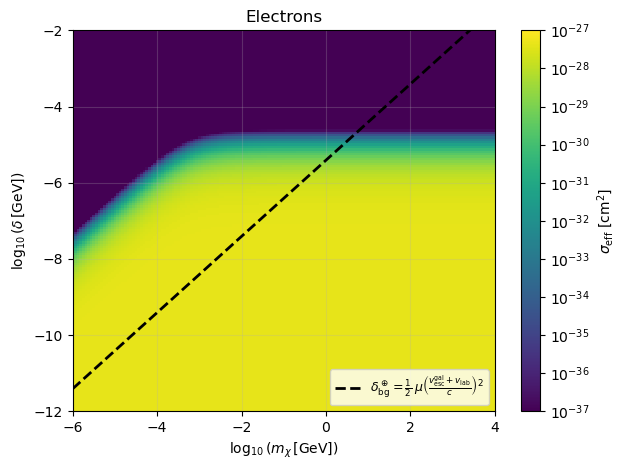

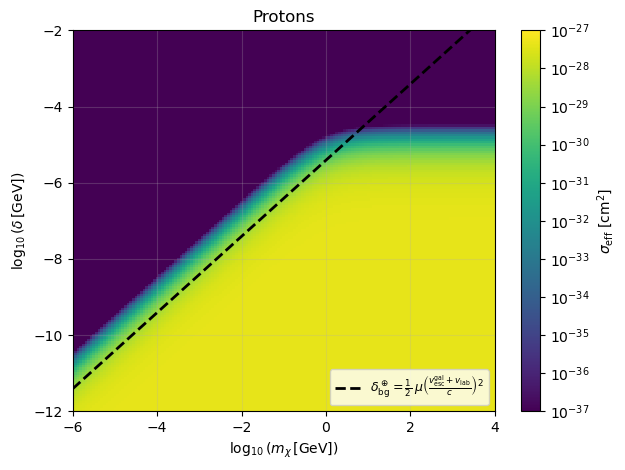

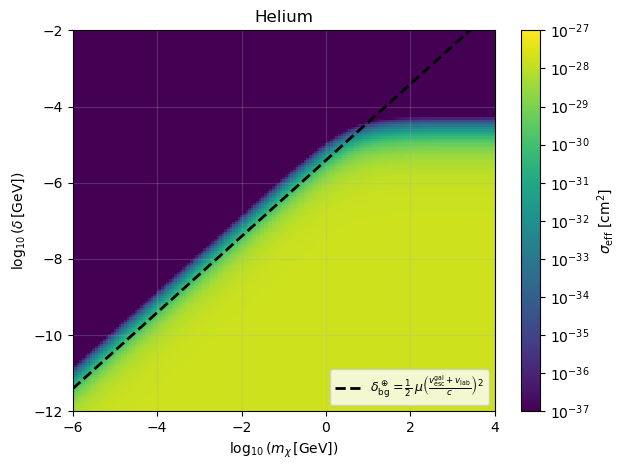

In [ ]:
    c_kms = 299_792.458 

    def F_phase(v, vdelta):
        z = 1.0 - (vdelta**2) / (v**2)
        return np.sqrt(np.maximum(z, 0.0))

    def g_rel(v, s_rel, U):
        v = np.asarray(v)
        if U <= 1e-14:
            return np.sqrt(2.0/np.pi) * (v**2) / (s_rel**3) * np.exp(-v**2/(2.0*s_rel**2))
        return (np.sqrt(2.0/np.pi) * v / (s_rel * U)
                * np.sinh(v*U/(s_rel**2))
                * np.exp(-(v**2 + U**2)/(2.0*s_rel**2)))

    def mu_red(m1_keV, m2_keV):
        return (m1_keV*m2_keV)/(m1_keV+m2_keV)

    # ---- ⟨σ_inel⟩_v for a given target (numerical v-integral; no escape cut) ----
    def sigma_inel_avg_T(mchi_keV, delta_keV, mT_keV, sigma_T_cm2,
                        s_chi_kms, U_kms):
        mu = mu_red(mchi_keV, mT_keV)
        vdelta = np.sqrt(2.0 * delta_keV / mu)          
        sT     = np.sqrt(Tcore_keV / mT_keV)            
        srel   = np.sqrt(sT**2 + (s_chi_kms/c_kms)**2) 
        U      = U_kms / c_kms

        v_max = min(0.5, U + 10.0*srel)                 
        if v_max <= vdelta:
            return 0.0

        # integrate in v (dense, but cheap)
        v = np.linspace(vdelta, v_max, 2000)
        integrand = g_rel(v, srel, U) * F_phase(v, vdelta)
        return sigma_T_cm2 * np.trapz(integrand, v)     # cm^2

    # ---- electrons: DM-at-rest approx => U=0, s_rel = sqrt(T/m_e) ----
    def sigma_eff_e(mchi_keV, delta_keV):
        mu_e   = mu_red(mchi_keV, me_keV)
        s_e    = np.sqrt(Tcore_keV / me_keV)
        vdelta = np.sqrt(2.0 * delta_keV / mu_e)
        v_max  = min(0.9, 10.0*s_e)
        if v_max <= vdelta:
            return 0.0
        v = np.linspace(vdelta, v_max, 2000)
        g = np.sqrt(2.0/np.pi) * v**2 / s_e**3 * np.exp(-v**2/(2.0*s_e**2))
        sig_avg = sigma_e_cm2 * np.trapz(g * F_phase(v, vdelta), v)
        n_e_rel = 1.0
        return n_e_rel * sig_avg

    # ---- nuclei: include Z^2 scaling and abundances (n_p=1, n_He=0.1) ----
    mp_keV, mHe_keV = 938_272.0813, 3_727_300.0

    def sigma_eff_p(mchi_keV, delta_keV, s_chi_kms, U_kms):
        sigma_T = sigma_e_cm2 * 1.0  # Z=1
        n_p_rel = 1.0
        return n_p_rel * sigma_inel_avg_T(mchi_keV, delta_keV, mp_keV, sigma_T, s_chi_kms, U_kms)

    def sigma_eff_He(mchi_keV, delta_keV, s_chi_kms, U_kms):
        sigma_T = sigma_e_cm2 * 4.0  # Z=2 -> Z^2=4
        n_He_rel = 0.1
        return n_He_rel * sigma_inel_avg_T(mchi_keV, delta_keV, mHe_keV, sigma_T, s_chi_kms, U_kms)

    
    mchi_grid_GeV  = np.logspace(-6,  4, 161)
    delta_grid_GeV = np.logspace(-12, -2, 161)

    MM_GeV, DD_GeV = np.meshgrid(mchi_grid_GeV, delta_grid_GeV, indexing='xy')

    Sigma_e  = np.zeros_like(MM_GeV)
    Sigma_p  = np.zeros_like(MM_GeV)
    Sigma_He = np.zeros_like(MM_GeV)

    U_sun_kms = 240.0
    s_chi_kms = v0_kms / np.sqrt(2.0)

    # ---- compute maps (convert δ[GeV] → δ[keV] for the physics) ----
    for i in range(MM_GeV.shape[0]):
        for j in range(MM_GeV.shape[1]):
            mchi_keV = MM_GeV[i,j] * 1e6         
            dlt_keV  = DD_GeV[i,j] * 1e6          
            Sigma_e[i,j]  = sigma_eff_e(mchi_keV, dlt_keV)
            Sigma_p[i,j]  = sigma_eff_p(mchi_keV, dlt_keV, s_chi_kms, U_sun_kms)
            Sigma_He[i,j] = sigma_eff_He(mchi_keV, dlt_keV, s_chi_kms, U_sun_kms)

    # ---------- continuous log colorbar fixed to 10^-32 … 10^-27 ----------
    norm = LogNorm(vmin=1e-37, vmax=1e-27)
    tick_locs = np.logspace(-37, -27, 11)  # 1e-37, 1e-36, …, 1e-27
    print("[colorbar] continuous log range: 1e-37 → 1e-27 cm^2")
    
    # ---------- Earth background line δ_bg(mχ) ----------
    v_esc_gal_kms = 600.0
    v_lab_kms     = 240.0
    beta_max = (v_esc_gal_kms + v_lab_kms) / c_kms  

    def delta_bg_GeV_line(mchi_GeV, mT_GeV=None):
        """Kinematic ceiling δ_bg^⊕ = 1/2 μ (v_max/c)^2.
        If mT_GeV is None we use the heavy-nucleus limit μ≈mχ."""
        if mT_GeV is None:
            mu_GeV = mchi_GeV
        else:
            mu_GeV = (mchi_GeV * mT_GeV) / (mchi_GeV + mT_GeV)
        return 0.5 * mu_GeV * beta_max**2

    # ---------- plotting (axes exactly like the example; δ in GeV), with bg line ----------
    def plot_sigma_eff_panel_logaxes_bracket(X_GeV, Y_GeV, Z_cm2, title):
        Xlog = np.log10(X_GeV)   # log10(mχ [GeV])
        Ylog = np.log10(Y_GeV)   # log10(δ [GeV])

        fig, ax = plt.subplots(figsize=(6.4,4.8))
        Z_clip = np.clip(Z_cm2, 1e-37, 1e-27)
        pcm = ax.pcolormesh(
            Xlog, Ylog, Z_clip,               
            shading='auto', cmap='viridis', norm=norm
        )

        # background line (heavy-nucleus limit μ≈mχ)
        xline = mchi_grid_GeV
        yline = delta_bg_GeV_line(xline)          
        ax.plot(np.log10(xline), np.log10(yline), 'k--', lw=2,
                label=r'$\delta^\oplus_{\rm bg}=\frac{1}{2}\,\mu\left(\frac{v_{\rm esc}^{\rm gal}+v_{\rm lab}}{c}\right)^{2}$')

        cb = fig.colorbar(pcm, ax=ax, ticks=tick_locs)
        cb.set_label(r'$\sigma_{\rm eff}\ [{\rm cm}^2]$')
        cb.formatter = mtick.LogFormatterMathtext()
        cb.update_ticks()

        ax.set_xlabel(r'$\log_{10}(m_\chi\,[\mathrm{GeV}])$')
        ax.set_ylabel(r'$\log_{10}(\delta\,[\mathrm{GeV}])$')
        ax.set_title(title)

        ax.set_xlim(-6, 4)
        ax.set_ylim(-12, -2)
        ax.set_xticks(np.arange(-6, 5, 2))
        ax.set_yticks(np.arange(-12, -1, 2))
        ax.grid(True, alpha=0.25)
        ax.legend(loc='lower right', fontsize=9)

        fig.tight_layout()
        plt.show()

    # draw the three panels
    plot_sigma_eff_panel_logaxes_bracket(MM_GeV, DD_GeV, Sigma_e,  'Electrons')
    plot_sigma_eff_panel_logaxes_bracket(MM_GeV, DD_GeV, Sigma_p,  'Protons')
    plot_sigma_eff_panel_logaxes_bracket(MM_GeV, DD_GeV, Sigma_He, 'Helium')


[colorbar] contour levels: 1e-37 … 1e-27 cm^2


/tmp/ipykernel_68518/1796053208.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


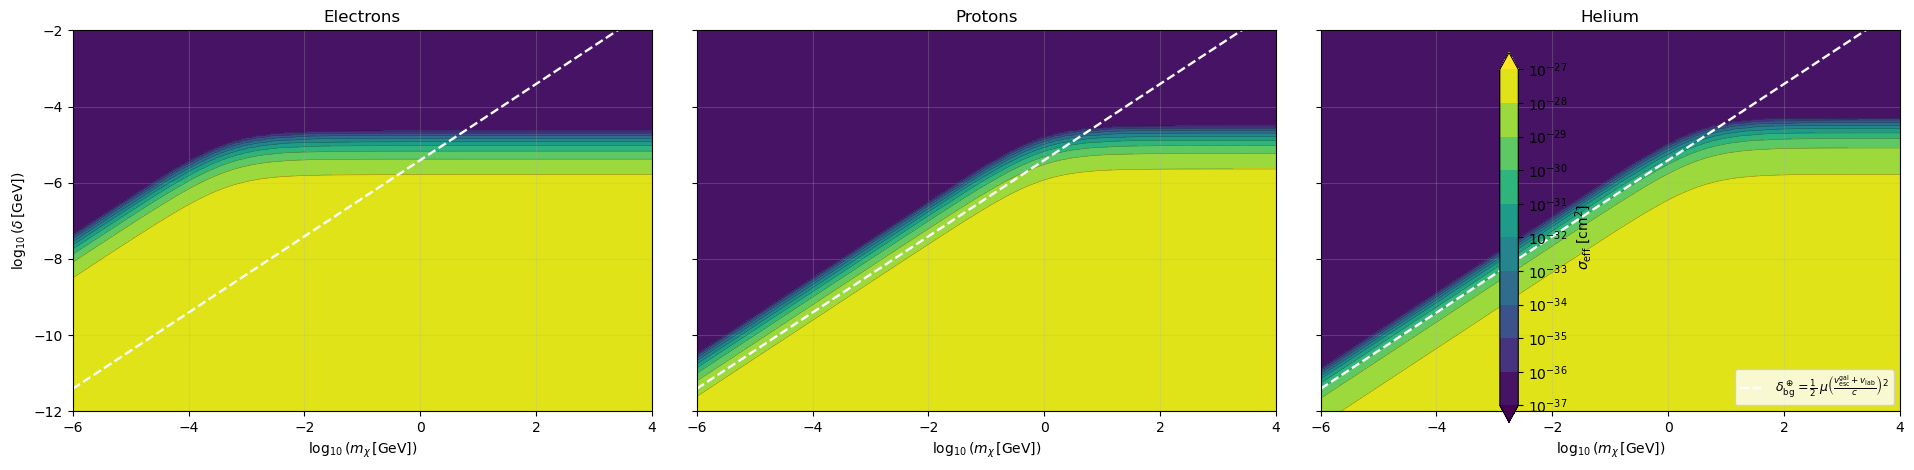

In [ ]:
c_kms = 299_792.458 

def F_phase(v, vdelta):
    z = 1.0 - (vdelta**2) / (v**2)
    return np.sqrt(np.maximum(z, 0.0))

def g_rel(v, s_rel, U):
    v = np.asarray(v)
    if U <= 1e-14:
        # zero-drift Maxwell
        return np.sqrt(2.0/np.pi) * (v**2) / (s_rel**3) * np.exp(-v**2/(2.0*s_rel**2))
    # non-central Maxwell
    return (np.sqrt(2.0/np.pi) * v / (s_rel * U)
            * np.sinh(v*U/(s_rel**2))
            * np.exp(-(v**2 + U**2)/(2.0*s_rel**2)))

def mu_red(m1_keV, m2_keV):
    return (m1_keV*m2_keV)/(m1_keV+m2_keV)

# ⟨σ_inel⟩_v for a given target (numerical v-integral; no escape cut)
def sigma_inel_avg_T(mchi_keV, delta_keV, mT_keV, sigma_T_cm2,
                     s_chi_kms, U_kms):
    mu = mu_red(mchi_keV, mT_keV)
    vdelta = np.sqrt(2.0 * delta_keV / mu)          
    sT     = np.sqrt(Tcore_keV / mT_keV)            
    srel   = np.sqrt(sT**2 + (s_chi_kms/c_kms)**2) 
    U      = U_kms / c_kms

    v_max = min(0.5, U + 10.0*srel)                
    if v_max <= vdelta:
        return 0.0

    v = np.linspace(vdelta, v_max, 2000)
    integrand = g_rel(v, srel, U) * F_phase(v, vdelta)
    return sigma_T_cm2 * np.trapz(integrand, v)     # cm^2

# ---- electrons: DM-at-rest approx => U=0, s_rel = sqrt(T/m_e) ----
def sigma_eff_e(mchi_keV, delta_keV):
    mu_e   = mu_red(mchi_keV, me_keV)
    s_e    = np.sqrt(Tcore_keV / me_keV)
    vdelta = np.sqrt(2.0 * delta_keV / mu_e)
    v_max  = min(0.9, 10.0*s_e)
    if v_max <= vdelta:
        return 0.0
    v = np.linspace(vdelta, v_max, 2000)
    g = np.sqrt(2.0/np.pi) * v**2 / s_e**3 * np.exp(-v**2/(2.0*s_e**2))
    sig_avg = sigma_e_cm2 * np.trapz(g * F_phase(v, vdelta), v)
    n_e_rel = 1.0
    return n_e_rel * sig_avg

# ---- nuclei: include Z^2 scaling and abundances (n_p=1, n_He=0.1) ----
mp_keV, mHe_keV = 938_272.0813, 3_727_300.0

def sigma_eff_p(mchi_keV, delta_keV, s_chi_kms, U_kms):
    sigma_T = sigma_e_cm2 * 1.0  # Z=1
    n_p_rel = 1.0
    return n_p_rel * sigma_inel_avg_T(mchi_keV, delta_keV, mp_keV, sigma_T, s_chi_kms, U_kms)

def sigma_eff_He(mchi_keV, delta_keV, s_chi_kms, U_kms):
    sigma_T = sigma_e_cm2 * 4.0  # Z=2 -> Z^2=4
    n_He_rel = 0.1
    return n_He_rel * sigma_inel_avg_T(mchi_keV, delta_keV, mHe_keV, sigma_T, s_chi_kms, U_kms)

# ---------- build grids (δ now in GeV on the plotting side) ----------
# x: log10(mchi[GeV]) in [-6, +4]
mchi_grid_GeV  = np.logspace(-6,  4, 161)
# y: log10(δ[GeV]) in [-12, -2]
delta_grid_GeV = np.logspace(-12, -2, 161)

MM_GeV, DD_GeV = np.meshgrid(mchi_grid_GeV, delta_grid_GeV, indexing='xy')

Sigma_e  = np.zeros_like(MM_GeV)
Sigma_p  = np.zeros_like(MM_GeV)
Sigma_He = np.zeros_like(MM_GeV)

U_sun_kms = 240.0
s_chi_kms = v0_kms / np.sqrt(2.0)

for i in range(MM_GeV.shape[0]):
    for j in range(MM_GeV.shape[1]):
        mchi_keV = MM_GeV[i,j] * 1e6         
        dlt_keV  = DD_GeV[i,j] * 1e6          
        Sigma_e[i,j]  = sigma_eff_e(mchi_keV, dlt_keV)
        Sigma_p[i,j]  = sigma_eff_p(mchi_keV, dlt_keV, s_chi_kms, U_sun_kms)
        Sigma_He[i,j] = sigma_eff_He(mchi_keV, dlt_keV, s_chi_kms, U_sun_kms)

norm = LogNorm(vmin=1e-37, vmax=1e-27)
levels = np.logspace(-37, -27, 11)  
print("[colorbar] contour levels: 1e-37 … 1e-27 cm^2")

v_esc_gal_kms = 600.0
v_lab_kms     = 240.0
beta_max = (v_esc_gal_kms + v_lab_kms) / c_kms  

def delta_bg_GeV_line(mchi_GeV, mT_GeV=None):
    """Kinematic ceiling δ_bg^⊕ = 1/2 μ (v_max/c)^2.
       If mT_GeV is None we use the heavy-nucleus limit μ≈mχ."""
    if mT_GeV is None:
        mu_GeV = mchi_GeV
    else:
        mu_GeV = (mchi_GeV * mT_GeV) / (mchi_GeV + mT_GeV)
    return 0.5 * mu_GeV * beta_max**2

Xlog = np.log10(MM_GeV)   
Ylog = np.log10(DD_GeV)   

fig, axes = plt.subplots(1, 3, figsize=(19.2, 4.8), sharex=True, sharey=True)

datasets = [
    (Sigma_e,  'Electrons'),
    (Sigma_p,  'Protons'),
    (Sigma_He, 'Helium')
]

for ax, (Z, title) in zip(axes, datasets):
    Z_clip = np.clip(Z, 1e-37, 1e-27)

    # Filled contour
    csf = ax.contourf(Xlog, Ylog, Z_clip, levels=levels, norm=norm, cmap='viridis', extend='both')
    # Thin contour lines on top
    ax.contour(Xlog, Ylog, Z_clip, levels=levels, norm=norm, colors='k', linewidths=0.35, alpha=0.5)

    # Earth background line (heavy-nucleus limit)
    xline = mchi_grid_GeV
    yline = delta_bg_GeV_line(xline)  # GeV
    ax.plot(np.log10(xline), np.log10(yline), 'w--', lw=1.7,
            label=r'$\delta^\oplus_{\rm bg}=\frac{1}{2}\,\mu\left(\frac{v_{\rm esc}^{\rm gal}+v_{\rm lab}}{c}\right)^{2}$')

    ax.set_title(title)
    ax.set_xlim(-6, 4)
    ax.set_ylim(-12, -2)
    ax.set_xticks(np.arange(-6, 5, 2))
    ax.set_yticks(np.arange(-12, -1, 2))
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel(r'$\log_{10}(\delta\,[\mathrm{GeV}])$')
for ax in axes:
    ax.set_xlabel(r'$\log_{10}(m_\chi\,[\mathrm{GeV}])$')

cbar = fig.colorbar(csf, ax=axes.ravel().tolist(), orientation='vertical', pad=0.02)
cbar.set_label(r'$\sigma_{\rm eff}\ [{\rm cm}^2]$')
cbar.set_ticks(levels)
cbar.formatter = mtick.LogFormatterMathtext()
cbar.update_ticks()

axes[-1].legend(loc='lower right', fontsize=9)

fig.tight_layout()
plt.show()

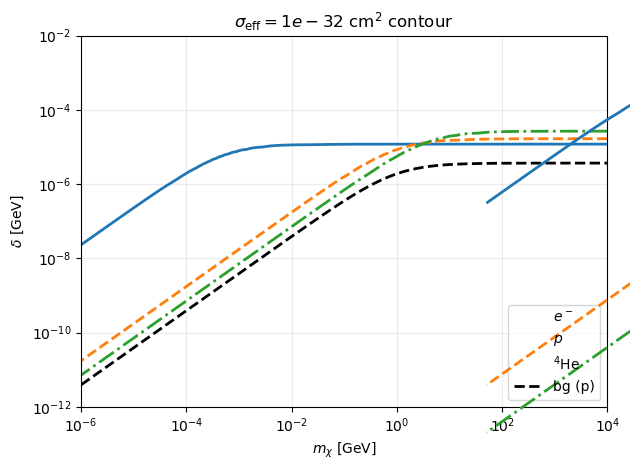

In [ ]:
cont_level = 1e-32

fig, ax = plt.subplots(figsize=(6.4,4.8))

#σ_eff contours
CS_e = ax.contour(
    MM_GeV, DD_GeV, Sigma_e,
    levels=[cont_level], colors=['tab:blue'], linewidths=2, linestyles='-'
)
CS_p = ax.contour(
    MM_GeV, DD_GeV, Sigma_p,
    levels=[cont_level], colors=['tab:orange'], linewidths=2, linestyles='--'
)
CS_He = ax.contour(
    MM_GeV, DD_GeV, Sigma_He,
    levels=[cont_level], colors=['tab:green'], linewidths=2, linestyles='-.'
)

v_esc_gal_kms = 600.0
v_lab_kms     = 240.0
beta_max      = (v_esc_gal_kms + v_lab_kms) / c_kms  
mp_GeV        = mp_keV * 1e-6                        

def delta_bg_GeV_line(mchi_GeV):
    """δ_bg^⊕ = 1/2 μ(mχ,m_p) ((v_esc^gal + v_lab)/c)^2."""
    mu_GeV = (mchi_GeV * mp_GeV) / (mchi_GeV + mp_GeV)
    return 0.5 * mu_GeV * beta_max**2

xline = np.geomspace(MM_GeV.min(), MM_GeV.max(), 400)
yline = delta_bg_GeV_line(xline)
BG, = ax.plot(
    xline, yline, 'k--', lw=2,
    label=r'$\delta^\oplus_{\rm bg}(p)=\tfrac12\,\mu(m_\chi,m_p)\!\left(\tfrac{v_{\rm esc}^{\rm gal}+v_{\rm lab}}{c}\right)^{2}$'
)

handles, labels = [], []
if CS_e.collections:  handles.append(CS_e.collections[0]);  labels.append(r'$e^-$')
if CS_p.collections:  handles.append(CS_p.collections[0]);  labels.append(r'$p$')
if CS_He.collections: handles.append(CS_He.collections[0]); labels.append(r'$^4\mathrm{He}$')
handles.append(BG); labels.append(r'bg (p)')
ax.legend(handles, labels, loc='lower right', frameon=True)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(MM_GeV.min(), MM_GeV.max())
ax.set_ylim(DD_GeV.min(), DD_GeV.max())
ax.set_xlabel(r'$m_\chi\ \mathrm{[GeV]}$')
ax.set_ylabel(r'$\delta\ \mathrm{[GeV]}$')
ax.set_title(rf'$\sigma_{{\rm eff}}={cont_level:.0e}\ \mathrm{{cm}}^2$ contour')
ax.grid(True, which='both', alpha=0.25)

plt.tight_layout()
plt.show()

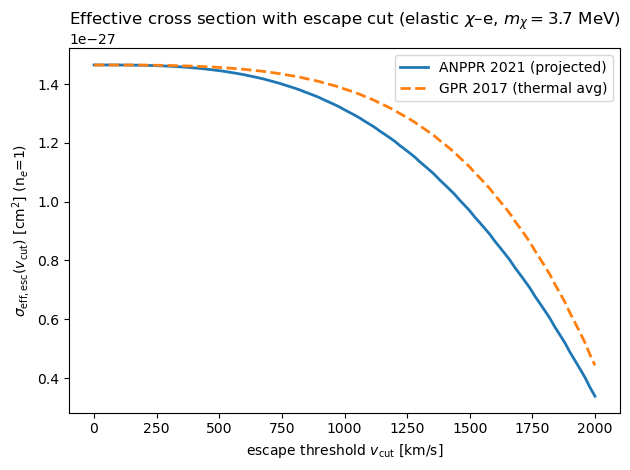

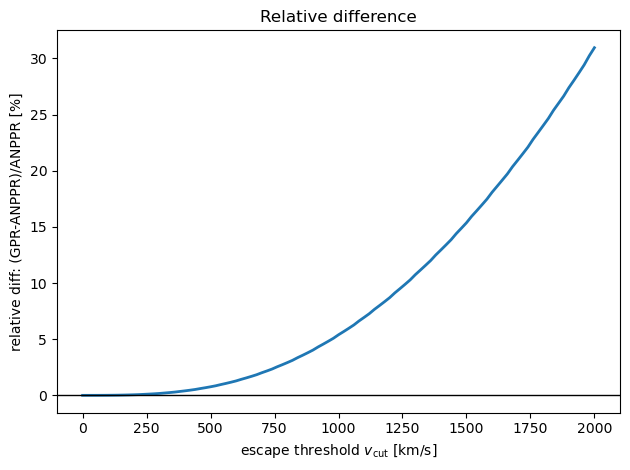

In [ ]:
c_kms = 299792.458

def kms_to_c(v_kms):
    return v_kms / c_kms

mchi_keV = 3.7e3      
me_keV   = 511.0      
T_keV    = 1.1       
sigma_T  = 1e-28   

vchi_kms = 800.0
vchi = kms_to_c(vchi_kms)

ue = np.sqrt(2.0*T_keV/me_keV)

# -----------------------------
# (A) ANPPR 2021 kernel -> dGamma/dv and σ_eff,esc(v_cut)
# -----------------------------
# We start from their Eq. (11) form:
# dΓ/(dq dcosθ_q) = N * q * exp( - [ (me/(2 mχ)) (2 k1 cosθ_q + q) + q/2 ]^2 / (2 me T) )
# with k1 = mχ vχ
# We project to v via the delta/Jacobian:
# dΓ/dv = (mχ^2 v / k1) ∫_{|k1 - mχ v|}^{k1 + mχ v} dq * [ dΓ/(dq dcosθ_q) at cosθ_q = cosθ*(v,q) ]
# where cosθ*(v,q) = (k1^2 + q^2 - mχ^2 v^2) / (2 k1 q)
#
# We'll determine N by requiring that ∫_0^∞ dv (dΓ/dv) = Γ_total from their Eq. (12):
# Γ_total = σ_tot n_e vχ * sqrt(T/me) * F(xχ), where xχ = vχ / sqrt(T/me),
# and F(x) = sqrt(1/(2π)) [ 2 e^{-x^2/2} + sqrt(2π)(1+x^2) erf(x/√2) ]
#
# Since we only compare σ_eff,esc (which divides out n_e), we'll set n_e=1.


def F_of_x(x):
    return np.sqrt(1.0/(2.0*np.pi))*( 2.0*np.exp(-0.5*x*x)
                                     + np.sqrt(2.0*np.pi)*(1.0+x*x)*erf(x/np.sqrt(2.0)) )

def Gamma_total_ANPPR(vchi, T_keV, me_keV, sigma_T, n_e=1.0):
    x = vchi/np.sqrt(T_keV/me_keV)
    return sigma_T * n_e * np.sqrt(T_keV/me_keV) * F_of_x(x)


def dGamma_dv_ANPPR(v, vchi, mchi_keV, me_keV, T_keV, sigma_T, N_norm):
    k1 = mchi_keV * vchi    
    k2 = mchi_keV * v
    qmin = abs(k1 - k2)
    qmax = (k1 + k2)
    if qmax <= 0:
        return 0.0
    q = np.linspace(qmin, qmax, 700)    
    with np.errstate(divide='ignore', invalid='ignore'):
        costh = (k1*k1 + q*q - k2*k2)/(2.0*k1*q)
    mask = (costh>=-1.0) & (costh<=1.0) & (q>0)
    if not np.any(mask):
        return 0.0
    q = q[mask]
    costh = costh[mask]
    term = (me_keV/(2.0*mchi_keV))*(2.0*k1*costh + q) + 0.5*q
    expo = np.exp( - (term*term)/(2.0*me_keV*T_keV) )
    integrand = q * expo
    integral_q = np.trapz(integrand, q)
    pref = (mchi_keV*mchi_keV * v) / (k1 + 1e-300)
    return N_norm * pref * integral_q

def build_ANPPR_spectrum(v_grid, vchi, mchi_keV, me_keV, T_keV, sigma_T):
    # Determine normalization N by enforcing integral over dv equals Γ_total
    tmp = np.array([dGamma_dv_ANPPR(v, vchi, mchi_keV, me_keV, T_keV, sigma_T, 1.0) for v in v_grid])
    integ = np.trapz(tmp, v_grid)
    Gamma_tot = Gamma_total_ANPPR(vchi, T_keV, me_keV, sigma_T)
    if integ <= 0:
        N = 0.0
    else:
        N = Gamma_tot/integ
    dGdv = tmp * N
    return dGdv, N, Gamma_tot

# -----------------------------
# (B) GPR-style: thermal average of dΓ/dv using isotropic CM contact scattering
# -----------------------------
# Start from the general lab→CM mapping (Appendix A of 1702):
#   dσ/dv = ∫_0^{2π} (dφ_st' / 2π) * [ dσ/dcosθ_cm ] * [ d(cosθ_st')/dv ] * Θ(1 - |cosθ_st'|).
#
# Lab-frame kinematics between final χ speed v, CM speed V, and relative speed w:
#   v^2 = V^2 + w^2 + 2 V w cosθ_st'
#   ⇒ cosθ_st'(v; V, w) = (v**2 - V**2 - w**2) / (2 V w)
#   ⇒ d(cosθ_st')/dv = v / (V w)
#   ⇒ Θ(1 - |cosθ_st'|) ↔ v ∈ [ |V - w| , V + w ] (triangle/kinematic window)
#
# For elastic, contact, isotropic scattering in the CM:
#   dσ/dΩ_cm = σ_T / (4π)  ⇒  dσ/dcosθ_cm = σ_T / 2  (angle-independent),
# and cosθ_st' has no φ_st' dependence, so ∫ dφ_st'/(2π) = 1.
#
# Therefore the speed-differential cross section used below is
#   dσ/dv = (σ_T/2) * (v / (V w)) * Θ(v - |V - w|) * Θ((V + w) - v) .
#
# This enters the rate kernel as
#   dΓ/dv = ∫ d^3u  n_e f(u) * w * [dσ/dv]
#         = n_e * (σ_T/2) * v * ∫ d^3u f(u) * [ (1/V) * Θ(v-window) ] .
#
# Maxwell–Boltzmann targets:
#   f_vec(u) = (1/(π**1.5 * u_e**3)) * exp(-u**2/u_e**2),  ∫ d^3u f_vec = 1
#   ⇒ speed pdf: P(u) du = 4π u**2 f_vec(u) du
#   with u_e = sqrt(2*T_keV/me_keV)  (natural units, c=1).
#
# Kinematics used in the integrand:
#   w(u, μ) = sqrt(vchi**2 + u**2 - 2*vchi*u*μ)
#   V(u, μ) = sqrt((mchi*vchi)**2 + (me*u)**2 + 2*(mchi*vchi)*(me*u)*μ) / (mchi + me)
#   window Θ: (v >= abs(V - w)) and (v <= V + w)

def f_MB_u(u, ue):
    return (1.0/(np.pi**1.5 * ue**3)) * np.exp(-(u*u)/(ue*ue))

def dGamma_dv_GPR(v, vchi, mchi_keV, me_keV, T_keV, sigma_T):
    ue_loc = np.sqrt(2.0*T_keV/me_keV)
    mu = mchi_keV*me_keV/(mchi_keV+me_keV)
    # integrate over u ∈ [0, u_max]; choose u_max ~ 6*ue
    u_max = 6.0*ue_loc
    u_grid = np.linspace(0.0, u_max, 600)
    total = 0.0
    for u in u_grid:
        weight_u = f_MB_u(u, ue_loc) * u*u
        mu_grid = np.linspace(-1.0, 1.0, 800)
        w = np.sqrt(vchi*vchi + u*u - 2.0*vchi*u*mu_grid)
        V = np.sqrt( (mchi_keV*vchi)**2 + (me_keV*u)**2 + 2.0*(mchi_keV*vchi)*(me_keV*u)*mu_grid ) / (mchi_keV+me_keV)
        vmin = np.abs(V - w)
        vmax = V + w
        window = (v >= vmin) & (v <= vmax) & (V>0) & (w>0)
        if not np.any(window):
            continue
        integrand_mu = np.zeros_like(mu_grid)
        integrand_mu[window] = (1.0/V[window])
        # integrate over cosθ
        I_mu = np.trapz(integrand_mu, mu_grid)
        total += weight_u * I_mu
    # To keep consistency, normalize so that ∫ dv dΓ/dv equals n_e σ_T vχ √(T/me) F(xχ) (same as ANPPR total rate).
    dGdv_unnorm = (sigma_T/2.0) * v * total * (1.0)  # leave normalization to be matched to Γ_total
    return dGdv_unnorm

def build_GPR_spectrum(v_grid, vchi, mchi_keV, me_keV, T_keV, sigma_T):
    tmp = np.array([dGamma_dv_GPR(v, vchi, mchi_keV, me_keV, T_keV, sigma_T) for v in v_grid])
    integ = np.trapz(tmp, v_grid)
    Gamma_tot = Gamma_total_ANPPR(vchi, T_keV, me_keV, sigma_T) 
    if integ <= 0:
        C = 0.0
    else:
        C = Gamma_tot/integ
    dGdv = tmp * C
    return dGdv, C, Gamma_tot

v_grid = np.linspace(0.0, kms_to_c(2200.0), 800)  # up to 2200 km/s

dGdv_A, NA, GtotA = build_ANPPR_spectrum(v_grid, vchi, mchi_keV, me_keV, T_keV, sigma_T)
dGdv_B, NB, GtotB = build_GPR_spectrum(v_grid, vchi, mchi_keV, me_keV, T_keV, sigma_T)

def sigma_eff_esc_from_spectrum(v_cut, v_grid, dGdv, vchi):
    mask = v_grid >= v_cut
    if not np.any(mask):
        return 0.0
    return np.trapz(dGdv[mask], v_grid[mask]) / (vchi + 1e-300)

vcut_grid_kms = np.linspace(0.0, 2000.0, 101)
vcut_grid = kms_to_c(vcut_grid_kms)
sigmaA = np.array([sigma_eff_esc_from_spectrum(vc, v_grid, dGdv_A, vchi) for vc in vcut_grid])
sigmaB = np.array([sigma_eff_esc_from_spectrum(vc, v_grid, dGdv_B, vchi) for vc in vcut_grid])

rel_diff = np.where(sigmaA>0, (sigmaB - sigmaA)/sigmaA, 0.0)

plt.figure(figsize=(6.4,4.8))
plt.plot(vcut_grid_kms, sigmaA, label='ANPPR 2021 (projected)', lw=2)
plt.plot(vcut_grid_kms, sigmaB, label='GPR 2017 (thermal avg)', lw=2, ls='--')
plt.xlabel(r'escape threshold $v_{\rm cut}$ [km/s]')
plt.ylabel(r'$\sigma_{\rm eff,esc}(v_{\rm cut})$ [cm$^2$] (n$_e$=1)')
plt.title(r'Effective cross section with escape cut (elastic $\chi$–e, $m_\chi=3.7$ MeV)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.4,4.8))
plt.plot(vcut_grid_kms, 100.0*rel_diff, lw=2)
plt.axhline(0, color='k', lw=1)
plt.xlabel(r'escape threshold $v_{\rm cut}$ [km/s]')
plt.ylabel('relative diff: (GPR-ANPPR)/ANPPR [%]')
plt.title('Relative difference')
plt.tight_layout()
plt.show()
